## 1.1 DeepLDA CV on pairwise distances (heavy atoms) 

### (a) Train CV

To load the PLUMED output of the two unbiased MD runs we can use the [load_dataframe](https://mlcvs.readthedocs.io/en/latest/autosummary/mlcvs.utils.io.load_dataframe.html) function.
From this data, we build our training dataset. Since this is a supervised learning task, the dataset will be of the form (`X,y`), in which `X` are the input samples and `y` the corresponding labels (the states to which they belong to).

In [1]:
import os
import subprocess
from pathlib import Path
import torch
import lightning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

In [2]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
#NUM_STEPS   = 10_000     # for testing  
NUM_STEPS   = 500_000    # productions
STRIDE      = 100

num_steps   = NUM_STEPS

os.chdir(BASE_DIR)

In [3]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [4]:
torch.set_float32_matmul_precision('high')

# Detect available accelerator
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {accelerator.upper()}")

Training on: GPU


### Load data


We use the alanine dipeptide simulation data from sample generation notebook

In [5]:
from mlcolvar.utils.io import create_dataset_from_files
from mlcolvar.data import DictModule

filenames = [ f"{DATA_DIR}/0_unbiased-sA/COLVAR", 
              f"{DATA_DIR}/0_unbiased-sB/COLVAR" ]

n_states = len(filenames)

# load dataset
dataset, df = create_dataset_from_files(filenames,
                                        filter_args={'regex':'d_' }, # select distances between heavy atoms
                                        create_labels=True,
                                        return_dataframe=True, 
                                        )

# default parameters batch size = len(dataset), shuffle = True
datamodule = DictModule(dataset,lengths=[0.8,0.2])

Class 0 dataframe shape:  (5001, 53)
Class 1 dataframe shape:  (5001, 53)

 - Loaded dataframe (10002, 53): ['time', 'phi', 'psi', 'theta', 'xi', 'ene', 'd_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15', 'd_11_16', 'd_11_17', 'd_11_19', 'd_15_16', 'd_15_17', 'd_15_19', 'd_16_17', 'd_16_19', 'd_17_19', 'walker', 'labels']
 - Descriptors (10002, 45): ['d_2_5', 'd_2_6', 'd_2_7', 'd_2_9', 'd_2_11', 'd_2_15', 'd_2_16', 'd_2_17', 'd_2_19', 'd_5_6', 'd_5_7', 'd_5_9', 'd_5_11', 'd_5_15', 'd_5_16', 'd_5_17', 'd_5_19', 'd_6_7', 'd_6_9', 'd_6_11', 'd_6_15', 'd_6_16', 'd_6_17', 'd_6_19', 'd_7_9', 'd_7_11', 'd_7_15', 'd_7_16', 'd_7_17', 'd_7_19', 'd_9_11', 'd_9_15', 'd_9_16', 'd_9_17', 'd_9_19', 'd_11_15

In [6]:
datamodule

DictModule(dataset -> DictDataset( "data": [10002, 45], "labels": [10002] ),
		     train_loader -> DictLoader(length=0.8, batch_size=0, shuffle=True),
		     valid_loader -> DictLoader(length=0.2, batch_size=0, shuffle=True))

We can inspect the distances through their histograms, from which we notice that no one is able to discriminate between the states.

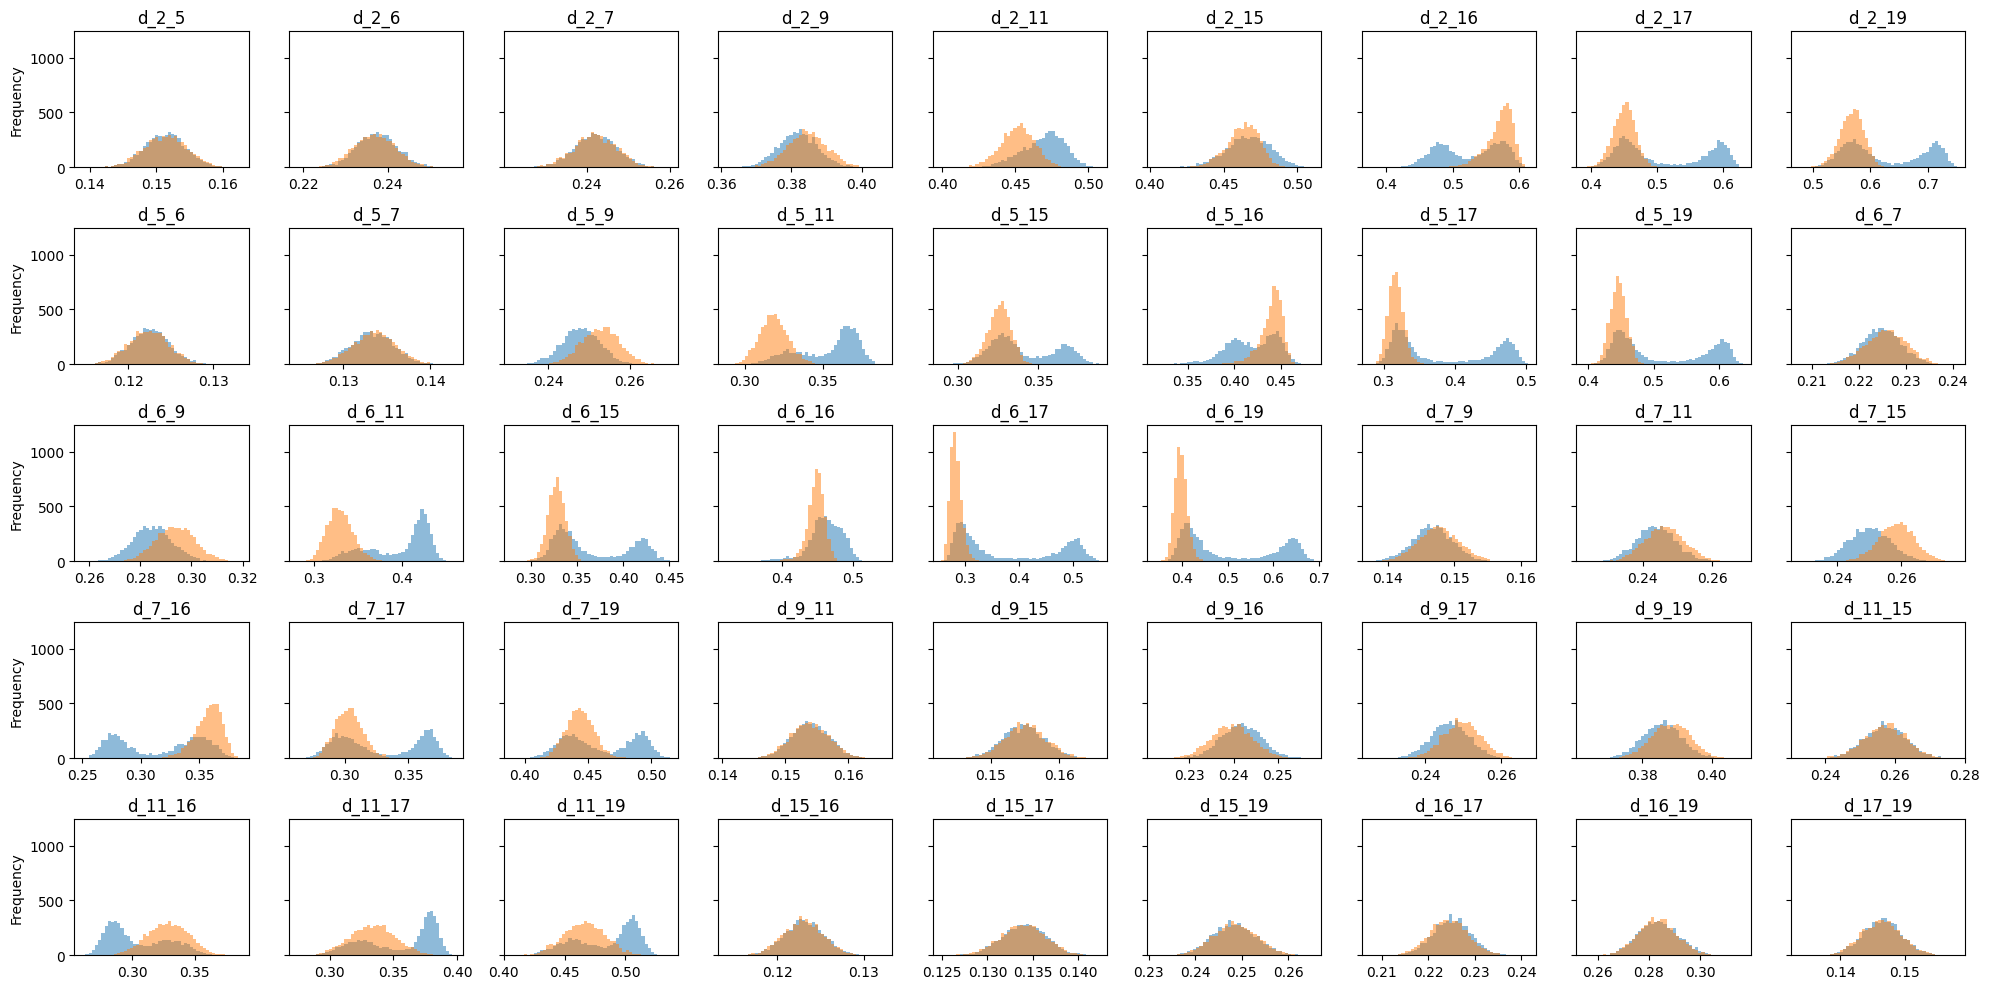

In [7]:
descriptors_names = df.filter(regex='d_').columns.values

fig,axs = plt.subplots(5,9,figsize=(20,10),sharey=True)

for ax,desc in zip(axs.flatten(),descriptors_names):
    df.pivot(columns='labels')[desc].plot.hist(bins=50,alpha=0.5,ax=ax,legend=False)
    ax.set_title(desc)

plt.tight_layout()

### Train DeepLDA 

Define model

In [8]:
from mlcolvar.cvs import DeepLDA

#------------- PARAMETERS -------------
n_input           = dataset['data'].shape[-1]
nodes             = [n_input,30,30,5]
activation        = 'tanh'

lrate             = 0.001
sw_reg            = 0.05
l2_reg            = 1e-5

num_epochs        = 500
es_patience       = 20
es_min_delta      = 0.1

log_every         = 100
#--------------------------------------

nn_args = {'activation': activation}
options= {'nn': nn_args}

# MODEL
model = DeepLDA(nodes, n_states=n_states, options=options)

# OPTIMIZER: here we use adam
model.optimizer_name = "Adam"
model.optimizer_kwargs = {"lr": lrate, "weight_decay": l2_reg}

# REGULARIZATION: add regularization to the calculation of the S_w matrix
model.sw_reg = sw_reg

model

DeepLDA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=45, out_features=45, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=45, out_features=30, bias=True)
      (1): Tanh()
      (2): Linear(in_features=30, out_features=30, bias=True)
      (3): Tanh()
      (4): Linear(in_features=30, out_features=5, bias=True)
    )
  )
  (lda): LDA(in_features=5, out_features=1)
)

Define trainer and fit

In [9]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", 
    min_delta=es_min_delta, 
    patience=es_patience,
    mode="min")

# define trainer
trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                     max_epochs=num_epochs, logger=None, enable_checkpointing=False)

# fit
trainer.fit( model, datamodule )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-07-03 12:06:35.857514: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-03 12:06:36.532537: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-03 12:06:38.395936: I tensorflow/core/util/port.cc:153] oneDNN cust

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃ In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ loss_fn │ ReduceEigenvaluesLoss │      0 │ train │     0 │        ? │         ? │
│ 1 │ norm_in │ Normalization         │      0 │ train │     0 │  [1, 45] │   [1, 45] │
│ 2 │ nn      │ FeedForward           │  2.5 K │ train │ 4.8 K │  [1, 45] │    [1, 5] │
│ 3 │ lda     │ LDA                   │      0 │ train │    10 │   [1, 5] │    [1, 1] │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┴──────────┴───────────┘

Trainable params: 2.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 K                                                                                                
Total estimated model params size (MB): 0.010                                                                      
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 4.8 K

Output()

/home/dani/ml/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches 
(1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if 
you want to see logs for the training epoch.

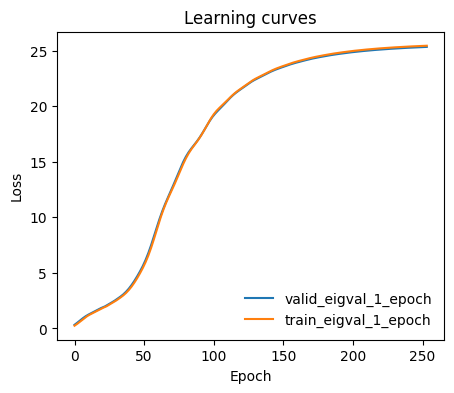

In [10]:
from mlcolvar.utils.plot import plot_metrics

ax = plot_metrics(metrics.metrics, 
                  keys=[x for x in  metrics.metrics.keys() if 'eigval' in x and 'epoch' in x],#['train_loss_epoch','valid_loss'],
                  yscale='linear')

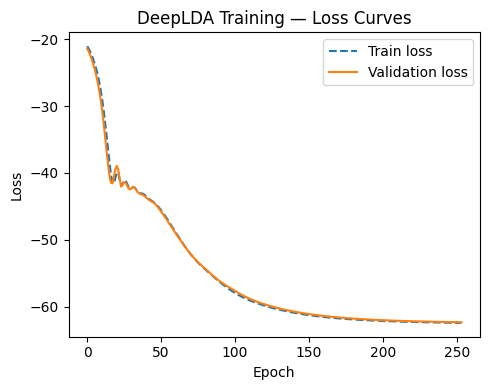

In [11]:
from mlcolvar.utils.plot import plot_metrics

ax = plot_metrics(metrics.metrics, 
                  keys=['train_loss_epoch','valid_loss'],
                  linestyles=['--','-'], #colors=['fessa1','fessa5'],
                  yscale='linear')

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("DeepLDA Training — Loss Curves")
ax.legend(["Train loss", "Validation loss"])

plt.tight_layout()

To better understand what the network is doing, we can inspect the output of the NN, before the application of LDA. 

--> **Question**: What are the differences with the input descriptors?